## PROJECT OVERVIEW

Netflix Data Analysis Using Python
Project Objective
This project aims to clean, explore and analyze the Netflix dataset to uncover trends in content distribution, ratings, countries, genres and release patterns through Exploratory Data Analysis and data visualization.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [74]:
df=pd.read_csv("netflix_titles.csv")

## DATA UNDERSTANDING

In [75]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [76]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [77]:
df.shape

(8807, 12)

## Dataset Shape

The netflix dataset contains 8807 rows and 12 columns, indicating 8807 netflix titles and 12 features describing each title.

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [79]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

## Data Types

The dataset contains 11 strings (textual informations) and 1 integer(whole numbers)

In [80]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [81]:
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

## Data Understanding Summary

| Feature | Observation |
|---------|-------------|
| Dataset Name | Netflix Titles Dataset
|
| Number of Rows | 8,807 |
| Number of Columns | 12 |
| Numerical Columns | 1 (release_year)
|
| Categorical Columns | 11 |
| Primary Key | show_id |
| Target of Analysis | Analyze Netflix content by type, country, release year, rating, genre, and duration. |
| Data Source | Netflix Titles Dataset (CSV) |

## DATA CLEANING

In [82]:
# Check missing values
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [83]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Not Available")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")
df["duration"] = df["duration"].fillna("Unknown")

In [84]:
df=df.dropna(subset=["date_added"])

In [85]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [86]:
#Check duplicate records
df.duplicated().sum()

np.int64(0)

In [87]:
# Remove duplicate rows 
df=df.drop_duplicates()

In [88]:
# Standardize column names
df.columns=df.columns.str.strip().str.lower().str.replace("","")
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [89]:
# Convert date_time to datetime
df["date_added"]=pd.to_datetime(df["date_added"],errors="coerce")
df["date_added"].dtype


dtype('<M8[us]')

In [90]:
df.info()

<class 'pandas.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   str           
 1   type          8797 non-null   str           
 2   title         8797 non-null   str           
 3   director      8797 non-null   str           
 4   cast          8797 non-null   str           
 5   country       8797 non-null   str           
 6   date_added    8709 non-null   datetime64[us]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   str           
 9   duration      8797 non-null   str           
 10  listed_in     8797 non-null   str           
 11  description   8797 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 893.4 KB


In [91]:
df.to_csv("netflix_titles_cleaned.csv",index=False)

## Data Cleaning Summary

| Cleaning Task | Action Taken | Result |
|---------------|--------------|--------|
| Checked Missing Values | Used `df.isnull().sum()` | Identified missing values in `director`, `cast`, `country`, `date_added`, `rating`, and `duration`. 
|
| Checked Duplicate Records | Used `df.duplicated().sum()` | No duplicate records found (0 duplicates).
|
| Removed Duplicates | Used `df.drop_duplicates()` | Dataset remained unchanged since no duplicates existed.
|
| Standardized Column Names | Converted column names to lowercase and replaced spaces with underscores | Column names are now consistent (e.g., `date_added`, `release_year`). 
|
| Converted Data Type | Converted `date_added` from string (`object`) to `datetime` | `date_added` is now stored as `datetime64`. 
|
| Handled Missing Values | Filled missing values in categorical columns and removed rows with missing `date_added` | Dataset contains no missing values. 
|
| Verified Cleaned Data | Used `df.info()` and `df.isnull().sum()` | Data is clean and ready for analysis. 
|
| Saved Cleaned Dataset | Used `df.to_csv("netflix_titles_cleaned.csv", index=False)` | Cleaned dataset saved successfully. |

## EXPLORATORY DATA ANALYSIS & VISUALIZATION

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

In [93]:
df["type"].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

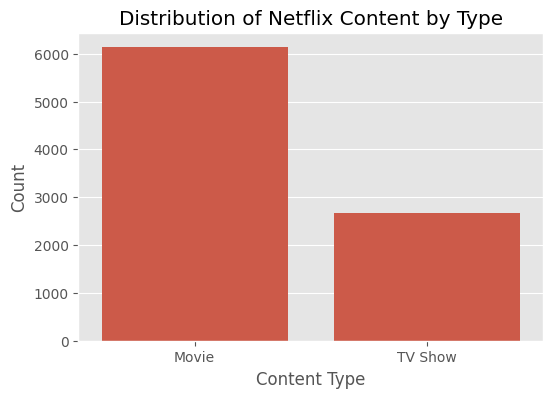

In [94]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="type")
plt.title("Distribution of Netflix Content by Type")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

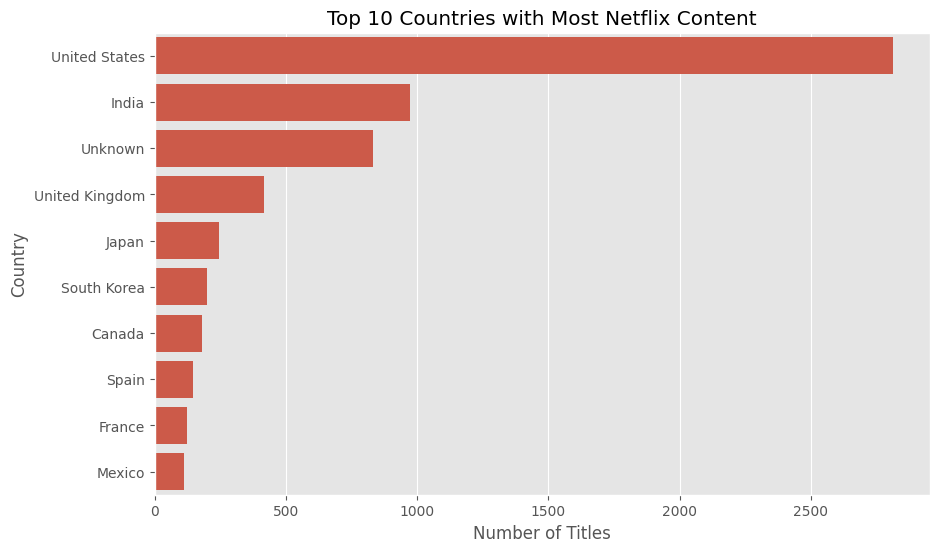

In [95]:
plt.figure(figsize=(10,6))

top_country = df["country"].value_counts().head(10)

sns.barplot(
    x=top_country.values,
    y=top_country.index
)

plt.title("Top 10 Countries with Most Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

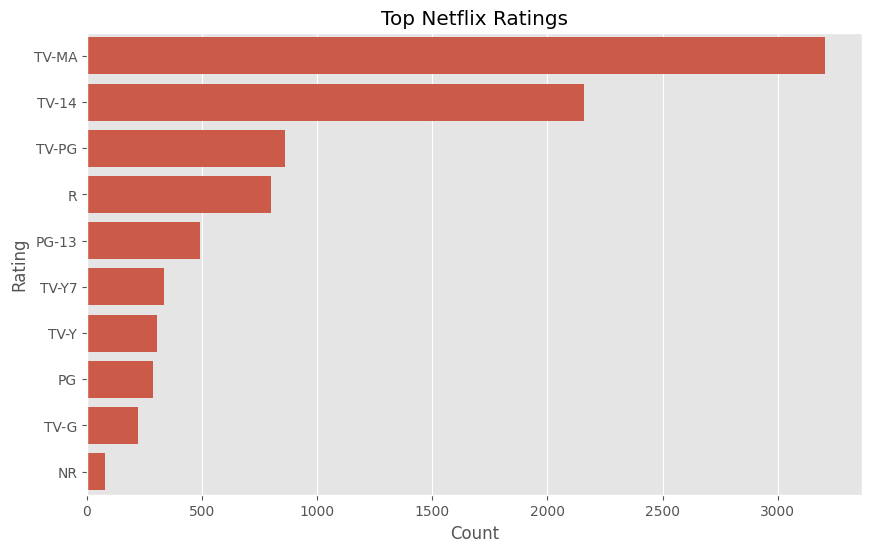

In [96]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().index[:10]
)

plt.title("Top Netflix Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

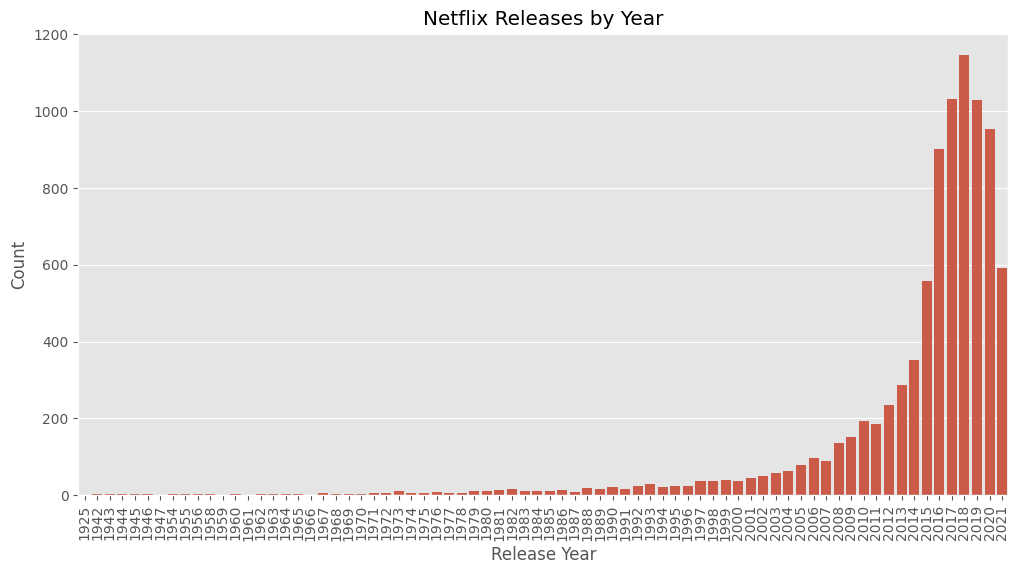

In [97]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="release_year",
    order=df["release_year"].value_counts().sort_index().index
)

plt.xticks(rotation=90)

plt.title("Netflix Releases by Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

In [98]:
df["listed_in"].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: str

In [99]:
genres=df["listed_in"].str.split(",").explode()

In [100]:
top_genres=genres.value_counts().head(10)
top_genres

listed_in
 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     773
 Independent Movies        736
 TV Dramas                 695
 Romantic Movies           613
Name: count, dtype: int64

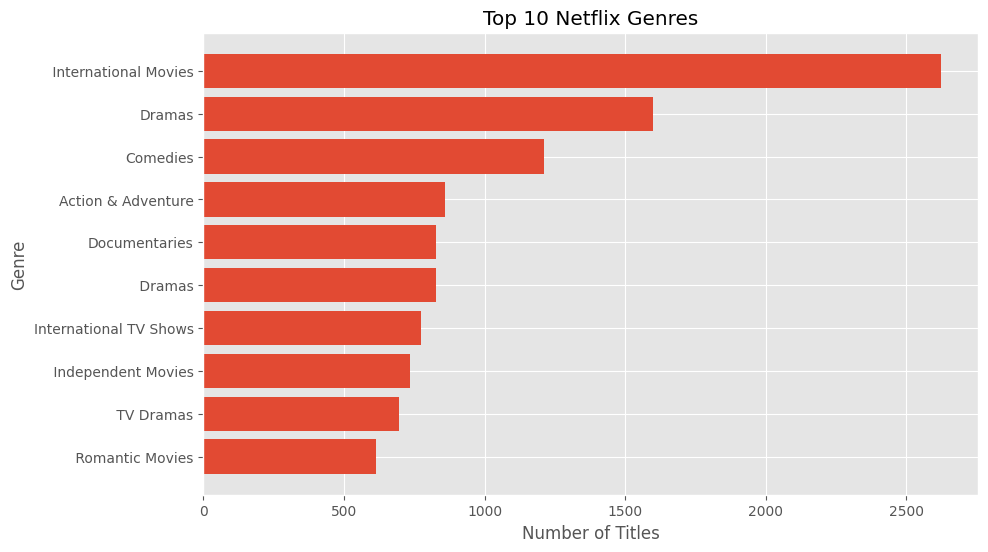

In [101]:
plt.figure(figsize=(10,6))

plt.barh(top_genres.index,top_genres.values)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.gca().invert_yaxis()

plt.show()

In [102]:
df=df.dropna(subset=["duration"])

In [103]:
df["duration"].isnull().sum()

np.int64(0)

In [104]:
df.shape

(8797, 12)

In [105]:
df=df[df["duration"]!="Unknown"]

In [106]:
movies = df[df["type"] == "Movie"].copy()

movies["duration"] = (movies["duration"]
    .str.replace(" min", "", regex=False)
    .astype(int))

In [107]:
movies["duration_group"] = pd.cut(movies["duration"],
    bins=[0, 60, 90, 120, 180, movies["duration"].max()],
    labels=[ "Less than 60 mins",
        "61–90 mins",
        "91–120 mins",
        "121–180 mins",
        "More than 180 mins"])

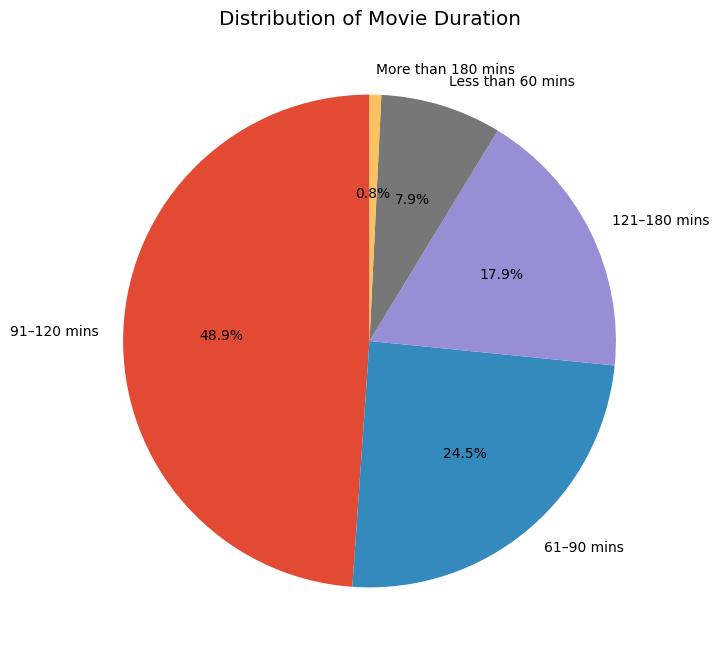

In [108]:
duration_counts = movies["duration_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    duration_counts,
    labels=duration_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Movie Duration")
plt.show()

## Findings Summary

| Visualization | Key Finding | Business Insight | Recommendation |
|---------------|-------------|------------------|----------------|
| Distribution of Netflix Content by Type | Movies make up the majority of Netflix's content library. | Netflix places greater emphasis on movies than TV shows, reflecting its content strategy | Continue investing in successful movie productions while expanding high-quality TV series to attract viewers who prefer long-form content.
|
| Top 10 Countries with Most Netflix Content | The United States has the highest number of Netflix titles. | Netflix has its strongest content presence in the U.S. market while continuing to expand globally. |Increase investment in original productions from underrepresented countries to broaden global appeal and content diversity.
|
| Top Netflix Ratings | TV-MA is the most common content rating. | Most Netflix titles are targeted at mature audiences, indicating strong demand for adult-oriented content. |Maintain a consistent release schedule and strengthen investments in original content to sustain user engagement throughout the year.
|
| Netflix Releases by Year | The number of releases increased significantly over the years before slowing down in recent years. | Netflix experienced rapid catalog growth, reflecting increased investment in original and licensed content. |Maintain a consistent release schedule and strengthen investments in original content to sustain user engagement throughout the year.
|
| Distribution of Movie Duration | Most movies fall within the 91–120 minute range. | Feature-length movies dominate Netflix's catalog, aligning with typical audience viewing preferences. |Prioritize producing movies within the 91–120 minute range while also introducing more short-form content for viewers seeking quicker entertainment.


## Recommendations

| **Finding** | **Recommendation** | **Expected Business Impact** |
|---------|----------------|--------------------------|
| Movies dominate Netflix's content library. | Continue investing in high-quality movie productions while maintaining a balanced mix of TV shows. | Improves viewer engagement and content diversity. 
|
| The United States contributes the highest number of titles. | Expand content production in emerging markets such as Africa, Asia, and Latin America to attract a wider global audience. | Increases regional representation and subscriber growth. 
|
| TV-MA is the most common rating. | Maintain a strong catalog for mature audiences while increasing family-friendly and children's content. | Broadens Netflix's audience and improves customer retention. 
|
| Netflix experienced significant growth in content releases over the years. | Sustain a consistent release schedule by balancing original productions with licensed content. | Keeps the content library fresh and encourages continuous subscriptions. 
|
| Most movies are between 91–120 minutes long. | Continue producing feature-length movies while introducing more short-form films for viewers with limited viewing time. | Provides greater viewing flexibility and appeals to different audience preferences. 


## Conclusion

This project explored the Netflix dataset through data understanding, data cleaning, exploratory data analysis, and visualization to uncover meaningful insights. The analysis showed that movies dominate the platform, the United States contributes the highest number of titles, TV-MA is the most common content rating, and most movies have a runtime of 91–120 minutes. These findings demonstrate how data analysis can transform raw data into actionable business insights that support strategic decision-making. The project also strengthened practical skills in Python, Pandas, Matplotlib, Seaborn, data cleaning, and exploratory data analysis.